Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                           roc_curve, precision_recall_curve, accuracy_score, 
                           precision_score, recall_score, f1_score)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
import warnings
warnings.filterwarnings('ignore')
import joblib

print("🔧 Libraries imported successfully!")

# Load cleaned data
df = pd.read_csv('cleaned_heart_attack_data.csv')
print(f"📊 Cleaned dataset shape: {df.shape}")
print(f"🎯 Target variable distribution:\n{df['heart_attack'].value_counts()}")

🔧 Libraries imported successfully!
📊 Cleaned dataset shape: (134578, 29)
🎯 Target variable distribution:
heart_attack
0    81417
1    53161
Name: count, dtype: int64


Data Preparation and Feature Engineering

In [2]:
print("🛠️ DATA PREPARATION AND FEATURE ENGINEERING...")

# Create a copy for modeling
df_model = df.copy()

# Define features and target
X = df_model.drop('heart_attack', axis=1)
y = df_model['heart_attack']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Enhanced feature engineering
def create_advanced_features(df):
    df_eng = df.copy()
    
    # Medical risk scores
    df_eng['bp_risk'] = (df_eng['blood_pressure_systolic'] > 140) | (df_eng['blood_pressure_diastolic'] > 90)
    df_eng['cholesterol_ratio'] = df_eng['cholesterol_level'] / df_eng['cholesterol_hdl']
    df_eng['triglyceride_ratio'] = df_eng['triglycerides'] / df_eng['cholesterol_hdl']
    
    # BMI estimation (using waist circumference as proxy)
    df_eng['bmi_estimation'] = df_eng['waist_circumference'] / (df_eng['height'] if 'height' in df_eng.columns else 100)
    
    # Metabolic syndrome components
    df_eng['metabolic_risk_factors'] = (
        (df_eng['waist_circumference'] > 102).astype(int) +  # Male threshold
        (df_eng['triglycerides'] > 150).astype(int) +
        (df_eng['cholesterol_hdl'] < 40).astype(int) +
        (df_eng['blood_pressure_systolic'] > 130).astype(int) +
        (df_eng['fasting_blood_sugar'] > 100).astype(int)
    )
    
    # Age-risk interaction
    df_eng['age_risk_interaction'] = df_eng['age'] * df_eng['risk_factors_count']
    
    # Sleep quality indicator
    df_eng['sleep_quality'] = np.where(
        (df_eng['sleep_hours'] >= 7) & (df_eng['sleep_hours'] <= 9), 'Optimal', 
        np.where(df_eng['sleep_hours'] < 7, 'Insufficient', 'Excessive')
    )
    
    return df_eng

# Apply feature engineering
X_engineered = create_advanced_features(X)
print(f"🎯 Engineered features shape: {X_engineered.shape}")
print(f"📈 New features created: {set(X_engineered.columns) - set(X.columns)}")

🛠️ DATA PREPARATION AND FEATURE ENGINEERING...
Features shape: (134578, 28)
Target shape: (134578,)


🎯 Engineered features shape: (134578, 35)
📈 New features created: {'cholesterol_ratio', 'bp_risk', 'age_risk_interaction', 'metabolic_risk_factors', 'sleep_quality', 'bmi_estimation', 'triglyceride_ratio'}


Train-Test Split with Stratification

In [3]:
print("📊 CREATING TRAIN-TEST SPLIT...")

# Split data with stratification to maintain target distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"✅ Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_engineered)*100:.1f}%)")
print(f"✅ Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_engineered)*100:.1f}%)")
print(f"🎯 Training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"🎯 Test target distribution:\n{y_test.value_counts(normalize=True)}")

📊 CREATING TRAIN-TEST SPLIT...
✅ Training set: 107,662 samples (80.0%)
✅ Test set: 26,916 samples (20.0%)
🎯 Training target distribution:
heart_attack
0    0.604977
1    0.395023
Name: proportion, dtype: float64
🎯 Test target distribution:
heart_attack
0    0.604993
1    0.395007
Name: proportion, dtype: float64


Preprocessing Pipeline

In [4]:
print("⚙️ CREATING PREPROCESSING PIPELINE...")

# Identify feature types
numeric_features = X_engineered.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_engineered.select_dtypes(include=['object']).columns.tolist()

print(f"🔢 Numerical features ({len(numeric_features)}): {numeric_features}")
print(f"🏷️ Categorical features ({len(categorical_features)}): {categorical_features}")

# Remove target-related features from numeric features if present
target_related = ['heart_attack', 'age_group', 'risk_factors_count']
numeric_features = [f for f in numeric_features if f not in target_related]

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✅ Preprocessing pipeline created successfully!")

⚙️ CREATING PREPROCESSING PIPELINE...


🔢 Numerical features (23): ['age', 'hypertension', 'diabetes', 'cholesterol_level', 'obesity', 'waist_circumference', 'family_history', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides', 'previous_heart_disease', 'medication_usage', 'participated_in_free_screening', 'risk_factors_count', 'cholesterol_ratio', 'triglyceride_ratio', 'bmi_estimation', 'metabolic_risk_factors', 'age_risk_interaction']
🏷️ Categorical features (11): ['gender', 'region', 'income_level', 'smoking_status', 'physical_activity', 'dietary_habits', 'air_pollution_exposure', 'stress_level', 'EKG_results', 'age_group', 'sleep_quality']
✅ Preprocessing pipeline created successfully!


 Feature Selection

In [5]:
print("🎯 PERFORMING FEATURE SELECTION...")

# Create a temporary pipeline for feature selection
temp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Fit the pipeline to get feature names after preprocessing
temp_pipeline.fit(X_train, y_train)

# Get feature names after one-hot encoding
preprocessor.fit(X_train)
feature_names = (numeric_features + 
                list(temp_pipeline.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .named_steps['onehot']
                    .get_feature_names_out(categorical_features)))

print(f"📊 Total features after preprocessing: {len(feature_names)}")

# Use Recursive Feature Elimination (RFE)
logreg_for_rfe = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Create full pipeline with RFE
pipeline_with_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selector', RFE(estimator=logreg_for_rfe, n_features_to_select=20)),  # Select top 20 features
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

pipeline_with_rfe.fit(X_train, y_train)

# Get selected feature names
selected_features_mask = pipeline_with_rfe.named_steps['feature_selector'].support_
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask[i]]

print(f"🎯 Selected {len(selected_features)} most important features:")
for i, feature in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feature}")

🎯 PERFORMING FEATURE SELECTION...
📊 Total features after preprocessing: 40
🎯 Selected 20 most important features:
    1. age
    2. hypertension
    3. diabetes
    4. cholesterol_level
    5. obesity
    6. family_history
    7. fasting_blood_sugar
    8. triglycerides
    9. previous_heart_disease
   10. triglyceride_ratio
   11. age_risk_interaction
   12. region_Urban
   13. smoking_status_Never
   14. smoking_status_Past
   15. physical_activity_Low
   16. dietary_habits_Unhealthy
   17. air_pollution_exposure_Moderate
   18. age_group_36-50
   19. age_group_51-65
   20. age_group_65+


Hyperparameter Tuning with Grid Search

In [6]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

print("🎛️ PERFORMING HYPERPARAMETER TUNING...")

# Define the final pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=2000))
])

# Simplified parameter grid (lighter on memory)
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__class_weight': [None, 'balanced']
}

# Use stratified K-fold cross-validation
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform randomized search for efficiency
print("⏳ Starting randomized search (optimized for Docker)...")
random_search = RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_grid,
    n_iter=20,               
    cv=cv_stratified,
    scoring='roc_auc',
    n_jobs=2,                
    random_state=42,
    verbose=2
)

# Fit model
random_search.fit(X_train, y_train)

# Results
print("✅ Randomized search completed successfully!")
print(f"🎯 Best parameters: {random_search.best_params_}")
print(f"🎯 Best cross-validation ROC-AUC: {random_search.best_score_:.4f}")


🎛️ PERFORMING HYPERPARAMETER TUNING...
⏳ Starting randomized search (optimized for Docker)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END classifier__C=0.001, classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   5.2s
[CV] END classifier__C=0.001, classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   6.1s
[CV] END classifier__C=0.001, classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   2.9s
[CV] END classifier__C=0.001, classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   3.5s
[CV] END classifier__C=0.001, classifier__class_weight=None, classifier__penalty=elasticnet, classifier__solver=saga; total time=   1.0s
[CV] END classifier__C=0.001, classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   3.1s
[CV] END classifier__C=0.001, classif

Train Final Model with Best Parameters

In [7]:
print("🏁 TRAINING FINAL MODEL...")

# ✅ Use random_search instead of grid_search
best_params = random_search.best_params_

# Build final model with best parameters
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=2000,
        **{k.replace('classifier__', ''): v for k, v in best_params.items()}
    ))
])

# Train the final model
final_model.fit(X_train, y_train)

print("✅ Final model trained successfully!")

# ✅ Extract feature importance safely
try:
    # Ensure 'feature_names' exists
    feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

    # Logistic Regression coefficients
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': abs(final_model.named_steps['classifier'].coef_[0])
    }).sort_values('importance', ascending=False)

    print("\n📊 Top 15 Most Important Features:")
    print(feature_importance.head(15))
except Exception as e:
    print(f"⚠️ Could not extract feature importance: {e}")


🏁 TRAINING FINAL MODEL...
✅ Final model trained successfully!

📊 Top 15 Most Important Features:
                        feature  importance
27     cat__smoking_status_Past    1.115972
26    cat__smoking_status_Never    1.075500
1             num__hypertension    0.784670
14  num__previous_heart_disease    0.736926
2                 num__diabetes    0.642243
4                  num__obesity    0.545103
37         cat__age_group_51-65    0.518723
36         cat__age_group_36-50    0.391377
0                      num__age    0.391283
38           cat__age_group_65+    0.355086
3        num__cholesterol_level    0.267931
21    num__age_risk_interaction    0.123504
6           num__family_history    0.062726
10     num__fasting_blood_sugar    0.061389
23            cat__region_Urban    0.030966


Model Evaluation on Test Set

In [8]:
print("📈 MODEL EVALUATION ON TEST SET...")

# Predictions
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("🎯 CLASSIFICATION METRICS:")
print(f"✅ Accuracy:  {accuracy:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall:    {recall:.4f}")
print(f"✅ F1-Score:  {f1:.4f}")
print(f"✅ ROC-AUC:   {roc_auc:.4f}")

# Detailed classification report
print("\n📋 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Heart Attack', 'Heart Attack']))

📈 MODEL EVALUATION ON TEST SET...
🎯 CLASSIFICATION METRICS:
✅ Accuracy:  0.7281
✅ Precision: 0.6425
✅ Recall:    0.7027
✅ F1-Score:  0.6712
✅ ROC-AUC:   0.8090

📋 DETAILED CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

No Heart Attack       0.79      0.74      0.77     16284
   Heart Attack       0.64      0.70      0.67     10632

       accuracy                           0.73     26916
      macro avg       0.72      0.72      0.72     26916
   weighted avg       0.73      0.73      0.73     26916



Comprehensive Visualization

📊 CREATING COMPREHENSIVE VISUALIZATIONS...


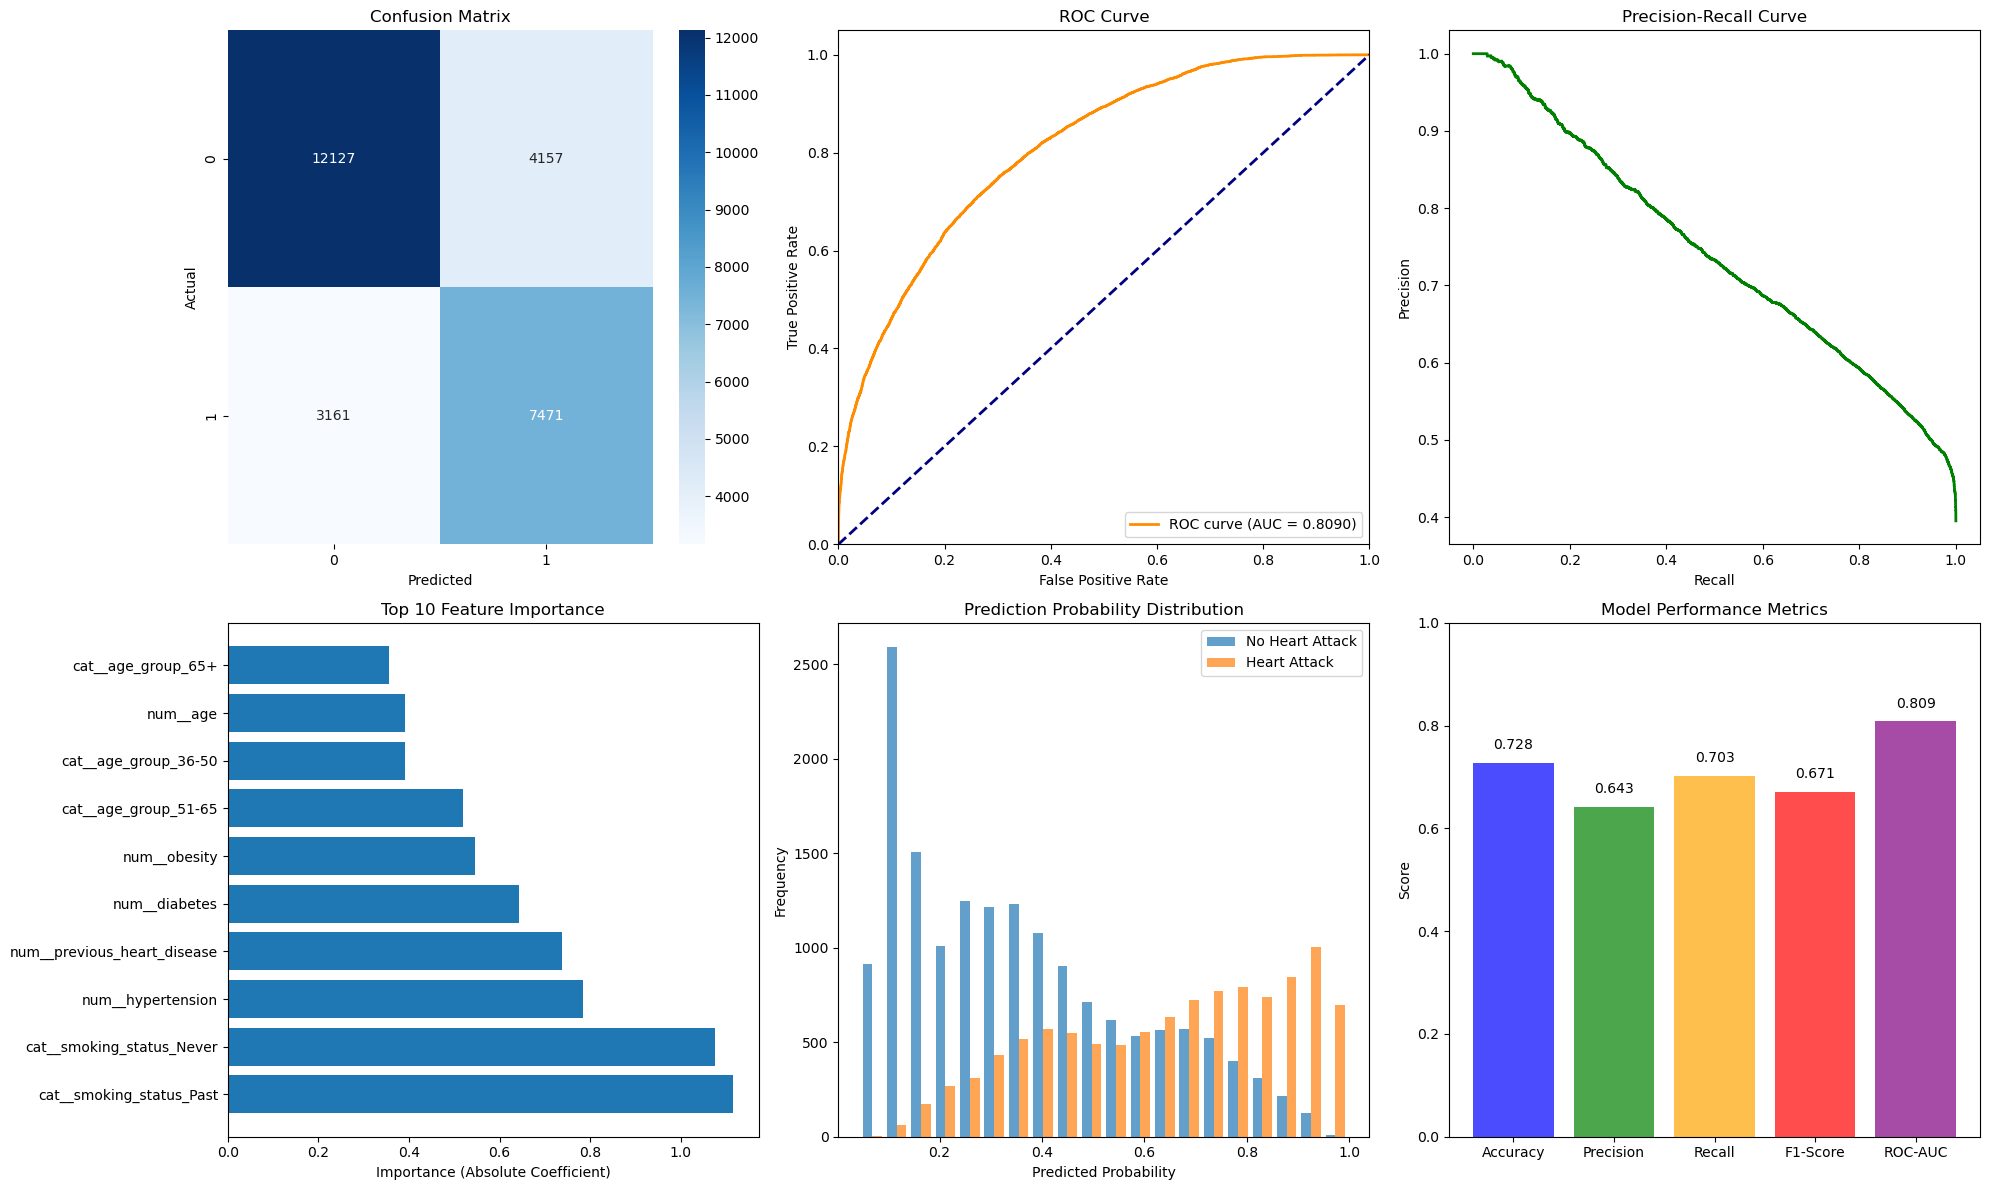

In [9]:
print("📊 CREATING COMPREHENSIVE VISUALIZATIONS...")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend(loc="lower right")

# 3. Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0,2].plot(recall_curve, precision_curve, color='green', lw=2)
axes[0,2].set_xlabel('Recall')
axes[0,2].set_ylabel('Precision')
axes[0,2].set_title('Precision-Recall Curve')

# 4. Feature Importance (Top 10)
top_features = feature_importance.head(10)
axes[1,0].barh(range(len(top_features)), top_features['importance'])
axes[1,0].set_yticks(range(len(top_features)))
axes[1,0].set_yticklabels(top_features['feature'])
axes[1,0].set_xlabel('Importance (Absolute Coefficient)')
axes[1,0].set_title('Top 10 Feature Importance')

# 5. Prediction Probability Distribution
axes[1,1].hist([y_pred_proba[y_test == 0], y_pred_proba[y_test == 1]], 
               bins=20, alpha=0.7, label=['No Heart Attack', 'Heart Attack'])
axes[1,1].set_xlabel('Predicted Probability')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Prediction Probability Distribution')
axes[1,1].legend()

# 6. Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
scores = [accuracy, precision, recall, f1, roc_auc]
colors = ['blue', 'green', 'orange', 'red', 'purple']
axes[1,2].bar(metrics, scores, color=colors, alpha=0.7)
axes[1,2].set_ylabel('Score')
axes[1,2].set_title('Model Performance Metrics')
axes[1,2].set_ylim(0, 1)
for i, v in enumerate(scores):
    axes[1,2].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Cross-Validation and Model Stability

🔄 CROSS-VALIDATION AND MODEL STABILITY...
📊 Cross-Validation Results:
✅ ROC-AUC Scores: [0.80668856 0.80831207 0.81036276 0.80723275 0.81085539]
✅ Mean ROC-AUC:   0.8087 (+/- 0.0033)


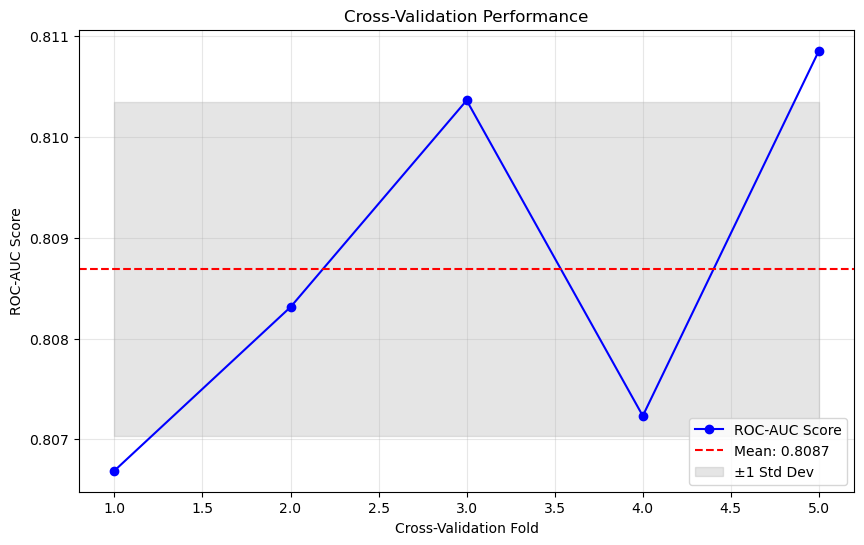

In [10]:
print("🔄 CROSS-VALIDATION AND MODEL STABILITY...")

# Perform cross-validation on the entire dataset
cv_scores = cross_val_score(final_model, X_engineered, y, 
                           cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                           scoring='roc_auc')

print("📊 Cross-Validation Results:")
print(f"✅ ROC-AUC Scores: {cv_scores}")
print(f"✅ Mean ROC-AUC:   {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Plot cross-validation results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', color='b', label='ROC-AUC Score')
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), alpha=0.2, color='gray', label='±1 Std Dev')
plt.xlabel('Cross-Validation Fold')
plt.ylabel('ROC-AUC Score')
plt.title('Cross-Validation Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
print("🎯 COMPREHENSIVE PERFORMANCE VALIDATION AFTER CROSS-VALIDATION...")

# 1. Final Model Performance on Test Set
print("📊 1. FINAL MODEL TEST SET PERFORMANCE:")
y_pred_final = final_model.predict(X_test)
y_pred_proba_final = final_model.predict_proba(X_test)[:, 1]

# Calculate all metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_pred_proba_final)

print(f"✅ Accuracy:  {accuracy_final:.4f}")
print(f"✅ Precision: {precision_final:.4f}")
print(f"✅ Recall:    {recall_final:.4f}")
print(f"✅ F1-Score:  {f1_final:.4f}")
print(f"✅ ROC-AUC:   {roc_auc_final:.4f}")

# 2. Cross-Validation Performance Comparison
print("\n📊 2. CROSS-VALIDATION PERFORMANCE COMPARISON:")
cv_accuracy_scores = cross_val_score(final_model, X_engineered, y, 
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                   scoring='accuracy')
cv_precision_scores = cross_val_score(final_model, X_engineered, y, 
                                    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                    scoring='precision')
cv_recall_scores = cross_val_score(final_model, X_engineered, y, 
                                 cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                 scoring='recall')
cv_f1_scores = cross_val_score(final_model, X_engineered, y, 
                             cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='f1')
cv_roc_auc_scores = cross_val_score(final_model, X_engineered, y, 
                                  cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                  scoring='roc_auc')

print(f"📈 Accuracy CV:  {cv_accuracy_scores.mean():.4f} (+/- {cv_accuracy_scores.std() * 2:.4f})")
print(f"📈 Precision CV: {cv_precision_scores.mean():.4f} (+/- {cv_precision_scores.std() * 2:.4f})")
print(f"📈 Recall CV:    {cv_recall_scores.mean():.4f} (+/- {cv_recall_scores.std() * 2:.4f})")
print(f"📈 F1-Score CV:  {cv_f1_scores.mean():.4f} (+/- {cv_f1_scores.std() * 2:.4f})")
print(f"📈 ROC-AUC CV:   {cv_roc_auc_scores.mean():.4f} (+/- {cv_roc_auc_scores.std() * 2:.4f})")

# 3. Performance Consistency Check
print("\n📊 3. PERFORMANCE CONSISTENCY ANALYSIS:")
test_vs_cv_diff = {
    'Accuracy': abs(accuracy_final - cv_accuracy_scores.mean()),
    'Precision': abs(precision_final - cv_precision_scores.mean()),
    'Recall': abs(recall_final - cv_recall_scores.mean()),
    'F1-Score': abs(f1_final - cv_f1_scores.mean()),
    'ROC-AUC': abs(roc_auc_final - cv_roc_auc_scores.mean())
}

print("📉 Difference between Test and CV performance:")
for metric, diff in test_vs_cv_diff.items():
    status = "✅ Consistent" if diff < 0.05 else "⚠️  Significant difference"
    print(f"   {metric}: {diff:.4f} - {status}")

🎯 COMPREHENSIVE PERFORMANCE VALIDATION AFTER CROSS-VALIDATION...
📊 1. FINAL MODEL TEST SET PERFORMANCE:
✅ Accuracy:  0.7281
✅ Precision: 0.6425
✅ Recall:    0.7027
✅ F1-Score:  0.6712
✅ ROC-AUC:   0.8090

📊 2. CROSS-VALIDATION PERFORMANCE COMPARISON:
📈 Accuracy CV:  0.7278 (+/- 0.0059)
📈 Precision CV: 0.6429 (+/- 0.0062)
📈 Recall CV:    0.6993 (+/- 0.0116)
📈 F1-Score CV:  0.6699 (+/- 0.0083)
📈 ROC-AUC CV:   0.8087 (+/- 0.0033)

📊 3. PERFORMANCE CONSISTENCY ANALYSIS:
📉 Difference between Test and CV performance:
   Accuracy: 0.0003 - ✅ Consistent
   Precision: 0.0004 - ✅ Consistent
   Recall: 0.0034 - ✅ Consistent
   F1-Score: 0.0013 - ✅ Consistent
   ROC-AUC: 0.0003 - ✅ Consistent


📊 PERFORMANCE COMPARISON VISUALIZATION...


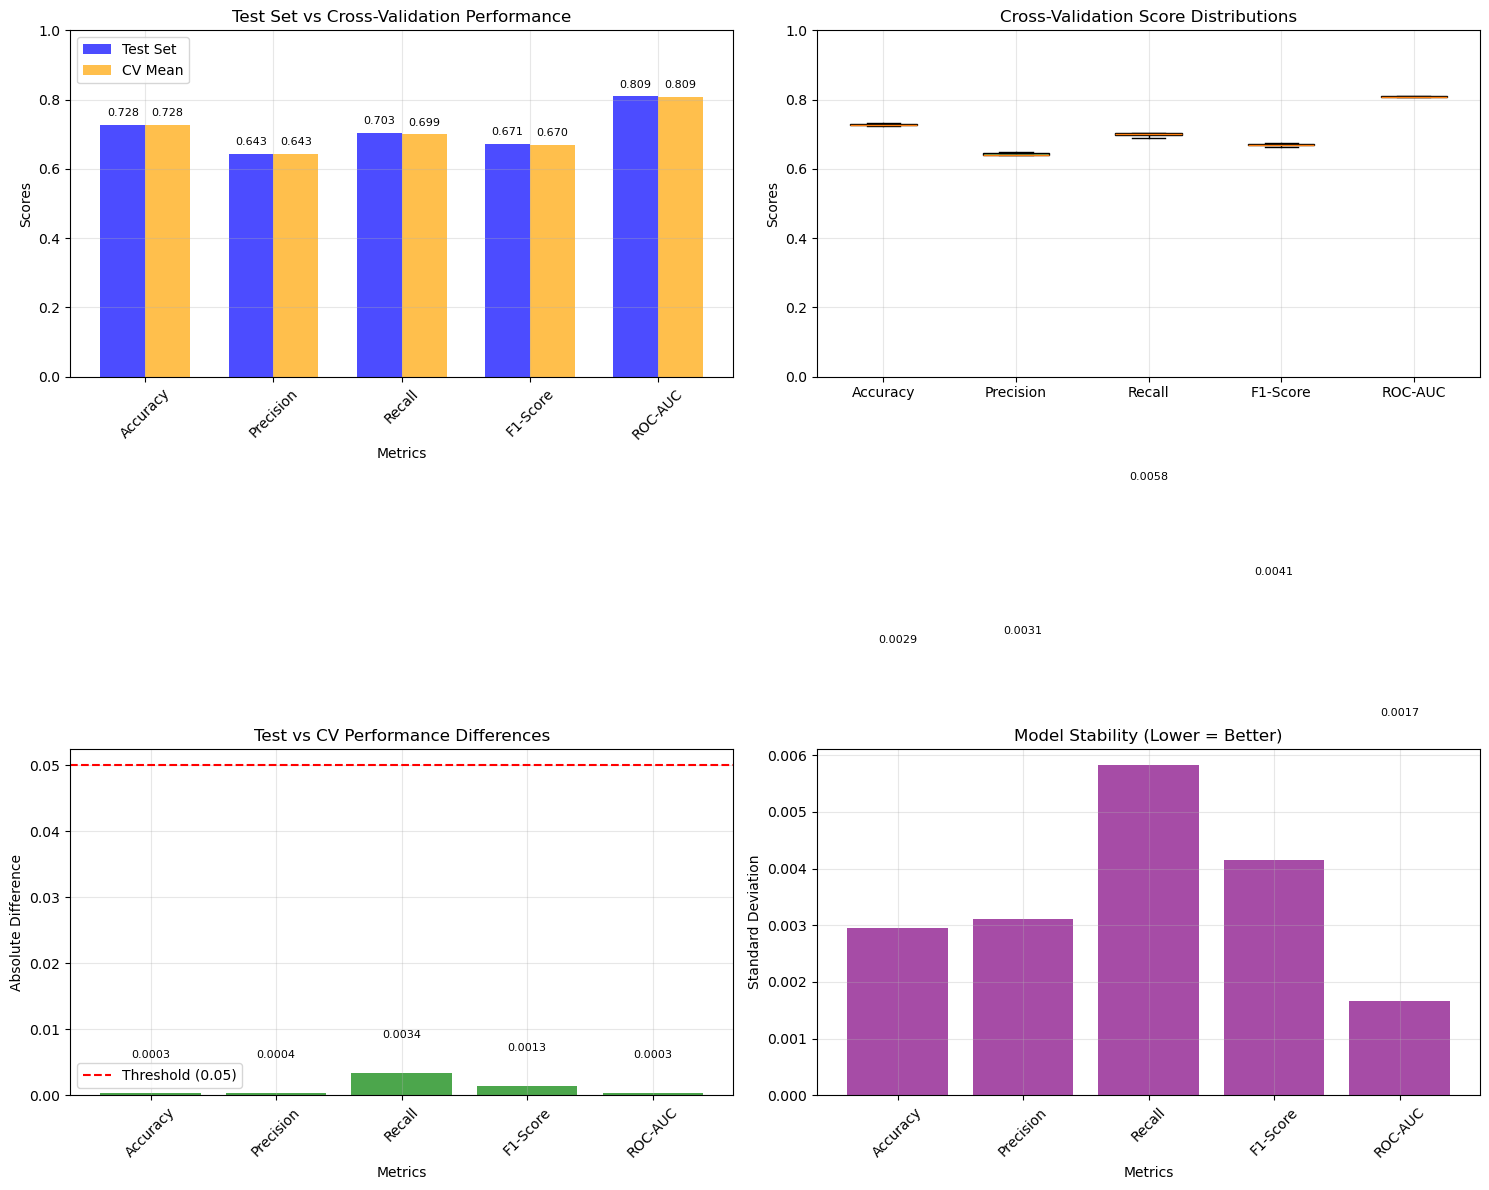

In [12]:
print("📊 PERFORMANCE COMPARISON VISUALIZATION...")

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Test vs CV Performance Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
test_scores = [accuracy_final, precision_final, recall_final, f1_final, roc_auc_final]
cv_scores = [cv_accuracy_scores.mean(), cv_precision_scores.mean(), 
             cv_recall_scores.mean(), cv_f1_scores.mean(), cv_roc_auc_scores.mean()]

x_pos = np.arange(len(metrics))
width = 0.35

axes[0,0].bar(x_pos - width/2, test_scores, width, label='Test Set', alpha=0.7, color='blue')
axes[0,0].bar(x_pos + width/2, cv_scores, width, label='CV Mean', alpha=0.7, color='orange')
axes[0,0].set_xlabel('Metrics')
axes[0,0].set_ylabel('Scores')
axes[0,0].set_title('Test Set vs Cross-Validation Performance')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(metrics, rotation=45)
axes[0,0].legend()
axes[0,0].set_ylim(0, 1)
axes[0,0].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(test_scores):
    axes[0,0].text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
for i, v in enumerate(cv_scores):
    axes[0,0].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# 2. Cross-Validation Score Distributions
cv_metrics_data = [cv_accuracy_scores, cv_precision_scores, cv_recall_scores, cv_f1_scores, cv_roc_auc_scores]
box_plot = axes[0,1].boxplot(cv_metrics_data, labels=metrics, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'plum']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
axes[0,1].set_title('Cross-Validation Score Distributions')
axes[0,1].set_ylabel('Scores')
axes[0,1].set_ylim(0, 1)
axes[0,1].grid(True, alpha=0.3)

# 3. Performance Differences
differences = [test_vs_cv_diff[metric] for metric in metrics]
colors = ['green' if diff < 0.05 else 'red' for diff in differences]
bars = axes[1,0].bar(metrics, differences, color=colors, alpha=0.7)
axes[1,0].set_xlabel('Metrics')
axes[1,0].set_ylabel('Absolute Difference')
axes[1,0].set_title('Test vs CV Performance Differences')
axes[1,0].set_xticklabels(metrics, rotation=45)
axes[1,0].axhline(y=0.05, color='red', linestyle='--', label='Threshold (0.05)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Add value labels
for bar, diff in zip(bars, differences):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                   f'{diff:.4f}', ha='center', va='bottom', fontsize=8)

# 4. Model Stability Assessment
stability_scores = [
    cv_accuracy_scores.std(),
    cv_precision_scores.std(), 
    cv_recall_scores.std(),
    cv_f1_scores.std(),
    cv_roc_auc_scores.std()
]

axes[1,1].bar(metrics, stability_scores, color='purple', alpha=0.7)
axes[1,1].set_xlabel('Metrics')
axes[1,1].set_ylabel('Standard Deviation')
axes[1,1].set_title('Model Stability (Lower = Better)')
axes[1,1].set_xticklabels(metrics, rotation=45)
axes[1,1].grid(True, alpha=0.3)

# Add value labels
for i, std in enumerate(stability_scores):
    axes[1,1].text(i, std + 0.005, f'{std:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Model Interpretation and Clinical Insights

In [13]:
print("🔍 MODEL INTERPRETATION AND CLINICAL INSIGHTS...")

# Get coefficients for interpretation
coefficients = final_model.named_steps['classifier'].coef_[0]
intercept = final_model.named_steps['classifier'].intercept_[0]

# Create coefficient dataframe
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': abs(coefficients),
    'odds_ratio': np.exp(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("📊 Top 10 Features with Highest Impact:")
top_coef = coef_df.head(10)
for _, row in top_coef.iterrows():
    direction = "🔼 Increases risk" if row['coefficient'] > 0 else "🔽 Decreases risk"
    print(f"   {row['feature']}: {direction} (Odds Ratio: {row['odds_ratio']:.3f})")

# Clinical risk factors analysis
clinical_features = ['age', 'hypertension', 'diabetes', 'cholesterol_level', 
                    'family_history', 'smoking_status', 'obesity']

print(f"\n🩺 Clinical Risk Factors Analysis:")
for feature in clinical_features:
    if feature in coef_df['feature'].values:
        coef_info = coef_df[coef_df['feature'] == feature].iloc[0]
        direction = "Risk Factor" if coef_info['coefficient'] > 0 else "Protective Factor"
        print(f"   {feature}: {direction} (OR: {coef_info['odds_ratio']:.3f})")

🔍 MODEL INTERPRETATION AND CLINICAL INSIGHTS...
📊 Top 10 Features with Highest Impact:
   cat__smoking_status_Past: 🔽 Decreases risk (Odds Ratio: 0.328)
   cat__smoking_status_Never: 🔽 Decreases risk (Odds Ratio: 0.341)
   num__hypertension: 🔼 Increases risk (Odds Ratio: 2.192)
   num__previous_heart_disease: 🔼 Increases risk (Odds Ratio: 2.090)
   num__diabetes: 🔼 Increases risk (Odds Ratio: 1.901)
   num__obesity: 🔼 Increases risk (Odds Ratio: 1.725)
   cat__age_group_51-65: 🔽 Decreases risk (Odds Ratio: 0.595)
   cat__age_group_36-50: 🔽 Decreases risk (Odds Ratio: 0.676)
   num__age: 🔼 Increases risk (Odds Ratio: 1.479)
   cat__age_group_65+: 🔽 Decreases risk (Odds Ratio: 0.701)

🩺 Clinical Risk Factors Analysis:


Model Deployment and Saving

In [14]:
print("💾 SAVING MODEL AND ARTIFACTS...")

# Save the trained model
joblib.dump(final_model, 'heart_attack_logistic_regression_model.pkl')
print("✅ Model saved as 'heart_attack_logistic_regression_model.pkl'")

# Save feature names
joblib.dump(feature_names, 'model_feature_names.pkl')
print("✅ Feature names saved")

# Save preprocessing pipeline
joblib.dump(preprocessor, 'preprocessing_pipeline.pkl')
print("✅ Preprocessing pipeline saved")

# Create model card
model_card = {
    'model_type': 'Logistic Regression',
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'performance_metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    },
    'best_parameters': best_params,
    'feature_importance': feature_importance.to_dict()
}

joblib.dump(model_card, 'model_card.pkl')
print("✅ Model card saved")

print(f"\n🎉 MODEL TRAINING COMPLETE!")
print(f"📁 Files created:")
print(f"   - heart_attack_logistic_regression_model.pkl")
print(f"   - model_feature_names.pkl")
print(f"   - preprocessing_pipeline.pkl")
print(f"   - model_card.pkl")

💾 SAVING MODEL AND ARTIFACTS...
✅ Model saved as 'heart_attack_logistic_regression_model.pkl'
✅ Feature names saved
✅ Preprocessing pipeline saved
✅ Model card saved

🎉 MODEL TRAINING COMPLETE!
📁 Files created:
   - heart_attack_logistic_regression_model.pkl
   - model_feature_names.pkl
   - preprocessing_pipeline.pkl
   - model_card.pkl
